<a href="https://colab.research.google.com/github/mrkarn007/Deep-Learning/blob/main/image_classification_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [66]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [67]:
train_images.shape

(50000, 32, 32, 3)

In [68]:
train_labels.shape

(50000, 1)

In [69]:
test_images.shape

(10000, 32, 32, 3)

In [70]:
test_labels.shape

(10000, 1)

In [71]:
train_labels[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [72]:
train_labels = train_labels.reshape(-1,)
train_labels

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [73]:
test_labels = test_labels.reshape(-1,)
test_labels

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

In [74]:
print(f"Data type of train_labels: {train_labels.dtype}")
print(f"Data type of test_labels: {test_labels.dtype}")

Data type of train_labels: uint8
Data type of test_labels: uint8


In [75]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [76]:
def plot_sample(X, y, index):
    plt.figure(figsize = (8,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

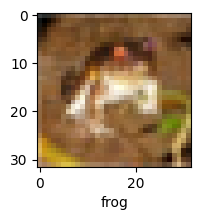

In [77]:
plot_sample(train_images, train_labels, 0)

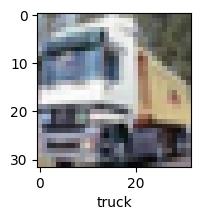

In [78]:
plot_sample(train_images, train_labels, 1)

In [79]:
train_images[:5]

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

In [80]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [81]:
train_labels

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [82]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(train_images, train_labels, epochs=5)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3528 - loss: 1.8172
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4272 - loss: 1.6250
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4551 - loss: 1.5420
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4778 - loss: 1.4812
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4989 - loss: 1.4295


In [83]:
y_pred = ann.predict(test_images)
y_pred_classes = [np.argmax(element) for element in y_pred]

y_pred_classes[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(4)]

In [85]:
from sklearn.metrics import confusion_matrix , classification_report
print("Classification Report: \n", classification_report(test_labels, y_pred_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.50      0.54      0.52      1000
           1       0.51      0.71      0.59      1000
           2       0.37      0.36      0.36      1000
           3       0.36      0.35      0.35      1000
           4       0.37      0.49      0.42      1000
           5       0.45      0.28      0.34      1000
           6       0.62      0.30      0.40      1000
           7       0.53      0.55      0.54      1000
           8       0.50      0.74      0.59      1000
           9       0.63      0.39      0.48      1000

    accuracy                           0.47     10000
   macro avg       0.48      0.47      0.46     10000
weighted avg       0.48      0.47      0.46     10000

